In [ ]:
import pandas as pd
import requests
import matplotlib.pyplot as plt

In [ ]:
class WeatherAPI:
  def __init__(self, location: str, url_address:str):
    self.location = location
    self.url_address = url_address.rstrip("/")
  def get_historical_data(self, start_data, end_data):
    data=pd.date_range(start=start_data, end=end_data)
    all_data=[]
    for single in data:
      data_str=single.strftime("%Y-%m-%d")
      url = f"{self.url_address}/stations/{self.location}/observations/{data_str}"
      response=requests.get(url)
      if response.status_code==200:
        data_info=response.json()
        observations=data_info.get("observations", [])
        for obs in observations:
          obs["time"]=obs.get("observationTimeUtc")
          all_data.append(obs)
    if not all_data:
            return pd.DataFrame()
    df=pd.DataFrame(all_data)
    df["time"]=pd.to_datetime(df["time"])
    df.set_index("time", inplace=True)
    df.index=pd.DatetimeIndex(df.index).tz_localize("UTC").tz_convert("Europe/Vilnius")
    return df
  def forecast_data(self, place: str="vilnius")-> pd.DataFrame:
      url=f"{self.url_address}/places/{place}/forecasts/long-term"
      response=requests.get(url)
      data=response.json()
      timestamps=data.get("forecastTimestamps", [])
      df=pd.DataFrame(timestamps)
      df["time"]=pd.to_datetime(df["forecastTimeUtc"])
      df.set_index("time", inplace=True)
      df_index=pd.DatetimeIndex(df.index).tz_localize("UTC").tz_convert("Europe/Vilnius")
      return df

client=WeatherAPI(location="vilniaus-ams", url_address="https://api.meteo.lt/v1")
print("Forecast data")
df_forecast=client.forecast_data(place="vilnius")
print(df_forecast.head())
print()
print("historical data")
df_historical=client.get_historical_data(start_data="2024-09-12", end_data="2025-09-12")
#df_historical = client.get_historical_data(start_data="2026-09-11", end_data="2026-09-13")
print(df_historical.head())


Forecast data
                         forecastTimeUtc  airTemperature  \
time                                                       
2026-09-12 11:00:00  2026-09-12 11:00:00            18.1   
2026-09-12 12:00:00  2026-09-12 12:00:00            18.2   
2026-09-12 13:00:00  2026-09-12 13:00:00            18.2   
2026-09-12 14:00:00  2026-09-12 14:00:00            18.0   
2026-09-12 15:00:00  2026-09-12 15:00:00            17.4   

                     feelsLikeTemperature  windSpeed  windGust  windDirection  \
time                                                                            
2026-09-12 11:00:00                  18.1          3         7            322   
2026-09-12 12:00:00                  18.2          2         7            326   
2026-09-12 13:00:00                  18.2          2         6            322   
2026-09-12 14:00:00                  18.0          2         6            306   
2026-09-12 15:00:00                  17.4          2         6            304  

In [ ]:
def calculate_metrics(df):
  if df.empty:
    print("Dataset is empty")
    return
  mean_temp=df["airTemperature"].mean()
  mean_humidity=df["relativeHumidity"].mean()
  print(f"Average temperature {mean_temp}")
  print(f"Average humidity {mean_humidity}")
  day, night=[], []
  for index, row in df.iterrows():
    hour=index.hour
    temp=row["airTemperature"]
    if 8<=hour<20:
      day.append(temp)
    else:
      night.append(temp)
  mean_day=sum(day)/len(day)
  mean_night=sum(night)/len(night)
  print(f"Average temperature during the day {mean_day}")
  print(f"Average temperature during the night {mean_night}")
  rain_cond=['rain', 'shower', 'drizzle', 'lietus']
  rainy_weekend=set()
  for index, row in df.iterrows():
    dayofweek=index.dayofweek
    if dayofweek in [5,6]:
      condition = str(row['conditionCode']).lower()
      precipitation=row.get('precipitation', 0)
      if any(rc in condition for rc in rain_cond) or precipitation>0:
        rainy_weekend.add(index.date())
  print(f"Rainy weekend {rainy_weekend}")
  print(f"Number of rainy weekend {len(rainy_weekend)}")
calculate_metrics(df_historical)

Average temperature 8.60979052823315
Average humidity 79.01229508196721
Average temperature during the day 10.04148451730419
Average temperature during the night 7.178096539162113
Rainy weekend {datetime.date(2024, 10, 13), datetime.date(2024, 9, 28), datetime.date(2025, 5, 24), datetime.date(2025, 7, 20), datetime.date(2025, 5, 4), datetime.date(2025, 3, 2), datetime.date(2025, 8, 16), datetime.date(2025, 5, 17), datetime.date(2025, 5, 11), datetime.date(2025, 7, 27), datetime.date(2025, 1, 26), datetime.date(2025, 2, 16), datetime.date(2025, 5, 10), datetime.date(2025, 6, 8), datetime.date(2025, 8, 23), datetime.date(2025, 8, 31), datetime.date(2024, 11, 16), datetime.date(2025, 6, 29), datetime.date(2025, 3, 16), datetime.date(2024, 10, 27), datetime.date(2024, 12, 22), datetime.date(2025, 8, 24), datetime.date(2024, 12, 8), datetime.date(2025, 5, 18), datetime.date(2025, 8, 17), datetime.date(2024, 12, 21), datetime.date(2025, 7, 19), datetime.date(2024, 10, 6), datetime.date(2025,

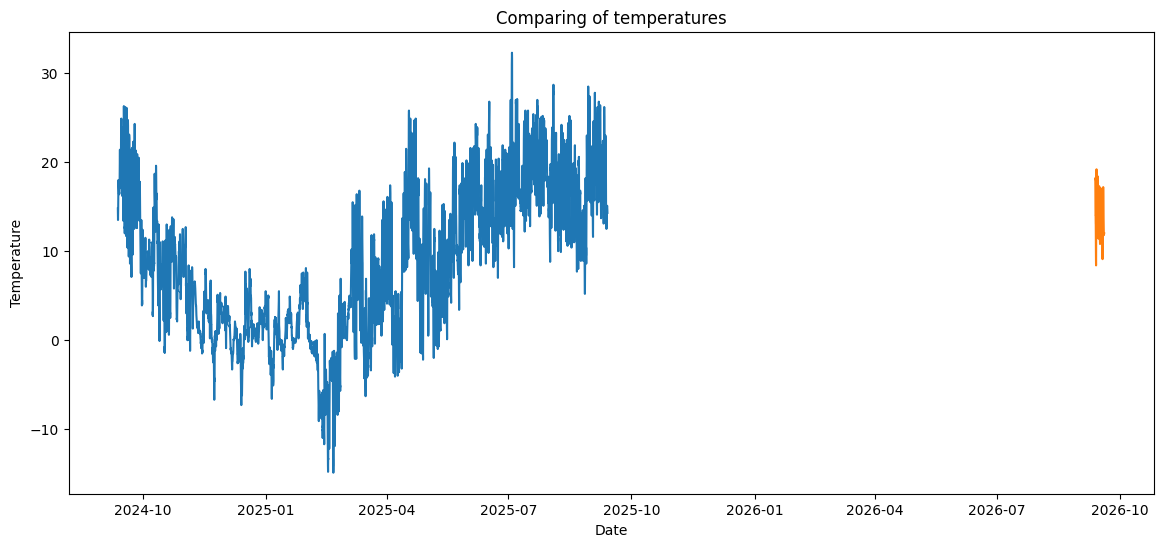

In [ ]:
hist_temp=df_historical['airTemperature']
forecast_temp=df_forecast['airTemperature']
combined=pd.concat([hist_temp, forecast_temp])
plt.figure(figsize=(14,6))
plt.plot(hist_temp.index, hist_temp)
plt.plot(forecast_temp.index, forecast_temp)
plt.title("Comparing of temperatures")
plt.xlabel("Date")
plt.ylabel("Temperature")
plt.show()

In [ ]:
df5min=df_historical.resample('5min').interpolate(method='linear')
print(df5min.head())

<bound method NDFrame.head of                             observationTimeUtc  airTemperature  \
time                                                             
2024-09-12 03:00:00+03:00  2024-09-12 00:00:00       14.800000   
2024-09-12 03:05:00+03:00                  NaN       14.725000   
2024-09-12 03:10:00+03:00                  NaN       14.650000   
2024-09-12 03:15:00+03:00                  NaN       14.575000   
2024-09-12 03:20:00+03:00                  NaN       14.500000   
...                                        ...             ...   
2025-09-13 01:40:00+03:00                  NaN       14.366667   
2025-09-13 01:45:00+03:00                  NaN       14.350000   
2025-09-13 01:50:00+03:00                  NaN       14.333333   
2025-09-13 01:55:00+03:00                  NaN       14.316667   
2025-09-13 02:00:00+03:00  2025-09-12 23:00:00       14.300000   

                           feelsLikeTemperature  windSpeed  windGust  \
time                                   

/tmp/ipykernel_1828/3947534542.py:1: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  df5min=df_historical.resample('5min').interpolate(method='linear')
